# 6,445 worlds beyond the Solar System, in plain SQL

**Every confirmed exoplanet in the NASA Exoplanet Archive**, one row per planet: how it was found, when, by which telescope, how big and how hot it is, what star it orbits. The core lesson of the data is about **selection**: what we have found says as much about our instruments as about the galaxy, so most queries compare *how* planets were found with *what* they look like. The SQL toolbox: a **median from `ROW_NUMBER`** (SQLite has none), pivots by conditional aggregation, `CASE` size classes, **`LAG` inside each planetary system** to get the period ratio of neighbouring planets, a similarity score to Earth, and a bulk density computed with `POWER`. Python only runs the queries and draws the charts.

**Data:** the [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/) *Planetary Systems Composite Parameters* table, fetched from its TAP service (CSV, about 1.4 MB, public data). Run `python build_db.py` once to download it into a SQLite database, then point `EXO_DB` at that file.

**Reading the data.** Each parameter is the best value assembled from different publications, so rows mix methods and precisions. **Nearly half of the masses (3,032 of 6,445) are not measured but estimated from the radius**, and another 941 are minimum masses (Msini), so the column `mass_source` matters whenever mass is used. The same holds for the radius: it is observed only for **transiting planets**, and for the others (radial velocity, microlensing, imaging) the archive lists a value estimated from the mass. So most planets have at most one of radius and mass measured, and every question about size below uses only transiting planets (`radius_source = 'measured (transit)'`). Many columns also have gaps (for example, the equilibrium temperature is missing for 8% of planets and the stellar age for 24%). 2026 is a partial year.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("EXO_DB", "exoplanets.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,planets,6445


## 1. How do we find planets?

Planets are counted by discovery method. SQLite has no median function, so the median observed mass per method is computed by numbering the planets with `ROW_NUMBER()` and averaging the middle one or two. Only planets whose mass was actually observed (measured, or a minimum mass from radial velocity) are used, not the masses estimated from the radius.

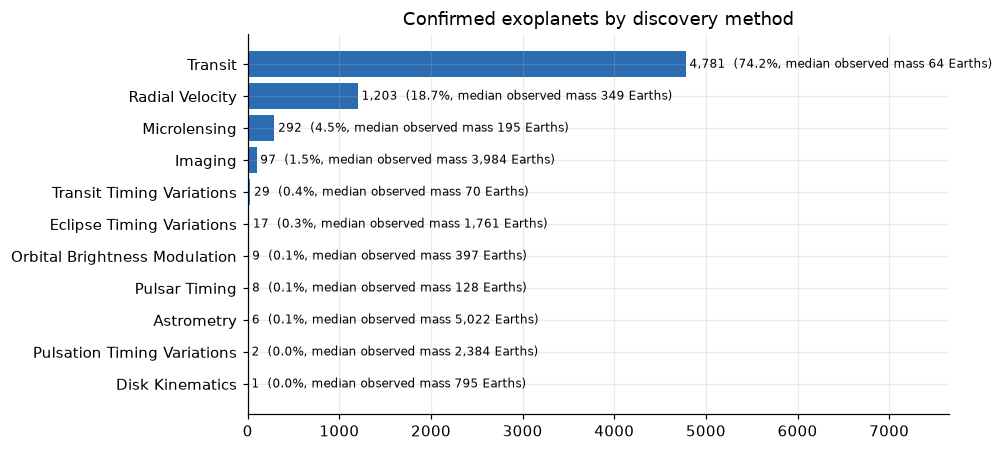

,method,planets,share_pct,first_year,median_observed_mass_earth,avg_distance_pc
0,Transit,4781,74.2,2002,64.0,579.0
1,Radial Velocity,1203,18.7,1995,349.0,84.0
2,Microlensing,292,4.5,2004,195.0,5586.0
3,Imaging,97,1.5,2004,3984.0,89.0


In [3]:
methods = q("""
WITH r AS (
    SELECT method, mass_earth,
           ROW_NUMBER() OVER (PARTITION BY method ORDER BY mass_earth) AS rn,
           COUNT(*)     OVER (PARTITION BY method)                     AS n
    FROM planets
    WHERE mass_source IN ('measured', 'minimum mass (Msini)') AND mass_earth > 0
),
med AS (
    SELECT method, AVG(mass_earth) AS median_mass
    FROM r
    WHERE rn IN ((n + 1) / 2, (n + 2) / 2)
    GROUP BY method
)
SELECT p.method,
       COUNT(*)                                            AS planets,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)  AS share_pct,
       MIN(p.disc_year)                                    AS first_year,
       ROUND(m.median_mass)                                AS median_observed_mass_earth,
       ROUND(AVG(p.distance_pc))                           AS avg_distance_pc
FROM planets p
LEFT JOIN med m USING (method)
GROUP BY p.method
ORDER BY planets DESC
""")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(methods.method[::-1], methods.planets[::-1], color=BLUE)
for y, (v, s, m) in enumerate(zip(methods.planets[::-1], methods.share_pct[::-1], methods.median_observed_mass_earth[::-1])):
    ax.text(v + 40, y, f"{v:,}  ({s}%, median observed mass {m:,.0f} Earths)" if m == m else f"{v:,}  ({s}%)", va="center", fontsize=8)
ax.set_xlim(0, methods.planets.max() * 1.6)
ax.set_title("Confirmed exoplanets by discovery method")
fig.tight_layout()
plt.show()
methods.head(4)

## 2. When were they found?

Counts per discovery year, pivoted by method with conditional sums, and a running total with `SUM() OVER`. The spikes in 2014 and 2016 are batch announcements from the Kepler team.

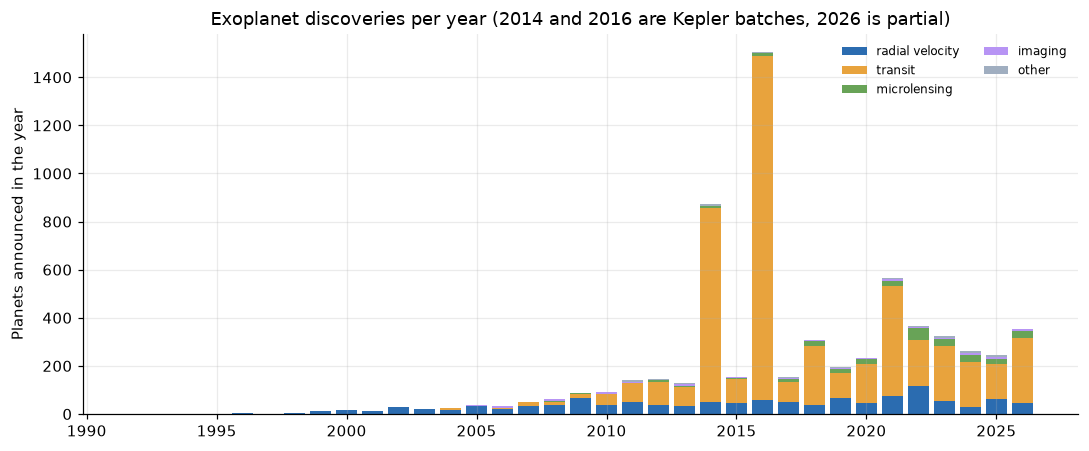

,year,planets,transit,radial_velocity,microlensing,imaging,other,total_so_far
23,2016,1504,1432,58,10,2,2,3442
21,2014,872,810,48,6,2,6,1783
28,2021,564,457,77,21,5,4,4894
29,2022,367,192,115,51,4,5,5261
33,2026,355,274,44,29,6,2,6445


In [4]:
by_year = q("""
WITH y AS (
    SELECT disc_year                                   AS year,
           COUNT(*)                                    AS planets,
           SUM(method = 'Transit')                     AS transit,
           SUM(method = 'Radial Velocity')             AS radial_velocity,
           SUM(method = 'Microlensing')                AS microlensing,
           SUM(method = 'Imaging')                     AS imaging,
           SUM(method NOT IN ('Transit', 'Radial Velocity', 'Microlensing', 'Imaging')) AS other
    FROM planets
    GROUP BY disc_year
)
SELECT year, planets, transit, radial_velocity, microlensing, imaging, other,
       SUM(planets) OVER (ORDER BY year) AS total_so_far
FROM y
ORDER BY year
""")

cols = ["radial_velocity", "transit", "microlensing", "imaging", "other"]
fig, ax = plt.subplots(figsize=(10, 4.2))
bottom = np.zeros(len(by_year))
for col, color in zip(cols, [BLUE, AMBER, "#68a357", "#b794f4", GREY]):
    ax.bar(by_year.year, by_year[col], bottom=bottom, label=col.replace("_", " "), color=color)
    bottom += by_year[col].values
ax.set_ylabel("Planets announced in the year")
ax.set_title("Exoplanet discoveries per year (2014 and 2016 are Kepler batches, 2026 is partial)")
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
plt.show()
by_year.sort_values("planets", ascending=False).head(5)

## 3. Which telescopes did the work?

Facility totals with a rank, the years they were active and whether they observe from space or from the ground.

In [5]:
facilities = q("""
SELECT RANK() OVER (ORDER BY COUNT(*) DESC)               AS rank,
       facility,
       MIN(locale)                                        AS locale,
       COUNT(*)                                           AS planets,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS share_pct,
       MIN(disc_year)                                     AS first_year,
       MAX(disc_year)                                     AS last_year
FROM planets
GROUP BY facility
ORDER BY planets DESC
LIMIT 12
""")

facilities

,rank,facility,locale,planets,share_pct,first_year,last_year
0,1,Kepler,Space,2787,43.2,2009,2026
1,2,Transiting Exoplanet Survey Satellite (TESS),Space,1008,15.6,2018,2026
2,3,K2,Space,550,8.5,2014,2026
3,4,Multiple Observatories,Ground,355,5.5,1996,2026
4,5,La Silla Observatory,Ground,311,4.8,1999,2026
5,6,W. M. Keck Observatory,Ground,193,3.0,1998,2026
6,7,KMTNet,Ground,147,2.3,2016,2026
7,8,SuperWASP,Ground,122,1.9,2007,2025
8,9,OGLE,Ground,112,1.7,2002,2026
9,10,HATSouth,Ground,73,1.1,2012,2021


## 4. What sizes of planet do we see?

A `CASE` sorts the transiting planets (the only ones with an observed radius) into size classes. For each class: its share, the share on very short orbits (under 10 days) and the average equilibrium temperature, which shows how strongly the transit method favours hot planets.

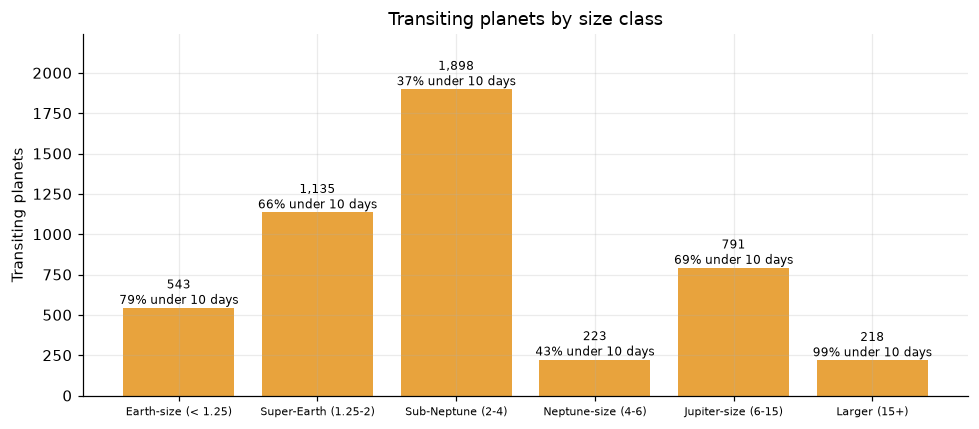

,size_class,planets,share_pct,orbit_under_10_days_pct,avg_eq_temp_k,avg_distance_pc
0,1) Earth-size (< 1.25),543,11.3,78.8,983.0,436.0
1,2) Super-Earth (1.25-2),1135,23.6,65.5,930.0,619.0
2,3) Sub-Neptune (2-4),1898,39.5,37.2,734.0,627.0
3,4) Neptune-size (4-6),223,4.6,43.0,810.0,694.0
4,5) Jupiter-size (6-15),791,16.5,69.0,1079.0,490.0
5,6) Larger (15+),218,4.5,98.6,1813.0,501.0


In [6]:
sizes = q("""
SELECT CASE WHEN radius_earth < 1.25 THEN '1) Earth-size (< 1.25)'
            WHEN radius_earth < 2    THEN '2) Super-Earth (1.25-2)'
            WHEN radius_earth < 4    THEN '3) Sub-Neptune (2-4)'
            WHEN radius_earth < 6    THEN '4) Neptune-size (4-6)'
            WHEN radius_earth < 15   THEN '5) Jupiter-size (6-15)'
            ELSE                          '6) Larger (15+)' END AS size_class,
       COUNT(*)                                                       AS planets,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)             AS share_pct,
       ROUND(100.0 * AVG(CASE WHEN period_days IS NOT NULL THEN period_days < 10 END), 1) AS orbit_under_10_days_pct,
       ROUND(AVG(eq_temp_k))                                          AS avg_eq_temp_k,
       ROUND(AVG(distance_pc))                                        AS avg_distance_pc
FROM planets
WHERE radius_source = 'measured (transit)' AND radius_earth IS NOT NULL
GROUP BY size_class
ORDER BY size_class
""")

fig, ax = plt.subplots(figsize=(9, 4))
labels = sizes.size_class.str[3:]
ax.bar(labels, sizes.planets, color=AMBER)
for x, (n, p) in enumerate(zip(sizes.planets, sizes.orbit_under_10_days_pct)):
    ax.text(x, n + 25, f"{n:,}\n{p:.0f}% under 10 days", ha="center", fontsize=8)
ax.set_ylim(0, sizes.planets.max() * 1.18)
ax.set_ylabel("Transiting planets")
ax.set_title("Transiting planets by size class")
ax.tick_params(axis="x", labelsize=7.5)
fig.tight_layout()
plt.show()
sizes

## 5. Is there a gap in planet sizes?

Transiting planets on short orbits (under 100 days) with radii between 1 and 4 Earths are binned in steps of 0.1 Earth radii with `ROUND(radius * 10) / 10`. Theory predicts a dip in the number of planets between the largest rocky ones and the smallest gaseous ones, and the histogram shows whether this sample reveals it.

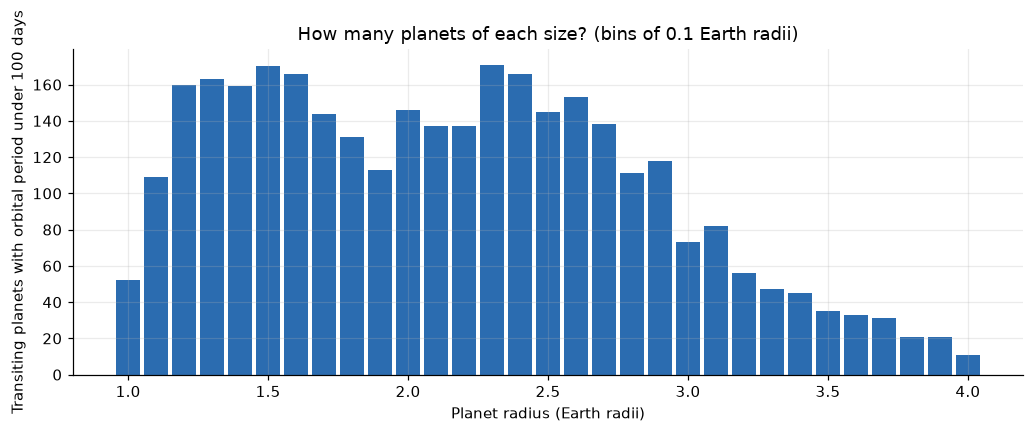

,radius_bin,planets
13,2.3,171
5,1.5,170
6,1.6,166
14,2.4,166
3,1.3,163


In [7]:
valley = q("""
SELECT ROUND(radius_earth * 10) / 10  AS radius_bin,
       COUNT(*)                       AS planets
FROM planets
WHERE radius_source = 'measured (transit)' AND radius_earth BETWEEN 1 AND 4 AND period_days < 100
GROUP BY radius_bin
ORDER BY radius_bin
""")

fig, ax = plt.subplots(figsize=(9.5, 3.9))
ax.bar(valley.radius_bin, valley.planets, width=0.085, color=BLUE)
ax.set_xlabel("Planet radius (Earth radii)")
ax.set_ylabel("Transiting planets with orbital period under 100 days")
ax.set_title("How many planets of each size? (bins of 0.1 Earth radii)")
fig.tight_layout()
plt.show()
valley.sort_values("planets", ascending=False).head(5)

## 6. Are hot Jupiters as common as they seem?

A *hot Jupiter* is a planet larger than 8 Earth radii with an orbit under 10 days. For each discovery year, the share of the year's newly found transiting planets (the ones with an observed radius) that are hot Jupiters shows how the sample changed as surveys got better at finding small planets.

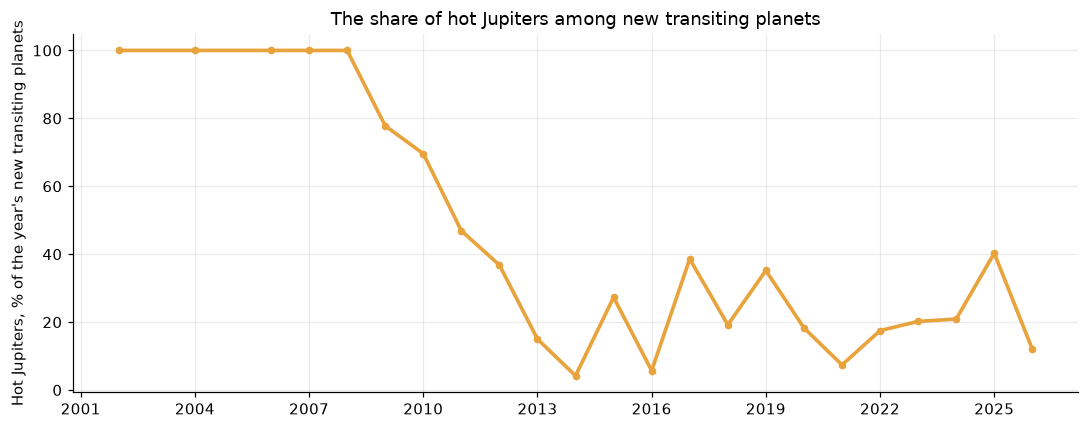

,year,planets,hot_jupiters,hot_jupiter_pct,smaller_than_2_earths
15,2019,108,38,35.2,37
16,2020,164,30,18.3,46
17,2021,458,34,7.4,160
18,2022,194,34,17.5,62
19,2023,228,46,20.2,61
20,2024,191,40,20.9,42
21,2025,149,60,40.3,27
22,2026,276,33,12.0,45


In [8]:
hot_jupiters = q("""
SELECT disc_year                                                          AS year,
       COUNT(*)                                                           AS planets,
       SUM(radius_earth > 8 AND period_days < 10)                         AS hot_jupiters,
       ROUND(100.0 * SUM(radius_earth > 8 AND period_days < 10) / COUNT(*), 1) AS hot_jupiter_pct,
       SUM(radius_earth < 2)                                              AS smaller_than_2_earths
FROM planets
WHERE radius_source = 'measured (transit)' AND radius_earth IS NOT NULL AND period_days IS NOT NULL
GROUP BY disc_year
ORDER BY disc_year
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hot_jupiters.year, hot_jupiters.hot_jupiter_pct, color=AMBER, marker="o", ms=4, lw=2.4)
ax.set_ylabel("Hot Jupiters, % of the year's new transiting planets")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title("The share of hot Jupiters among new transiting planets")
fig.tight_layout()
plt.show()
hot_jupiters.tail(8)

## 7. How are planets in a system spaced?

Inside each system, `LAG(period_days) OVER (PARTITION BY host ORDER BY period_days)` gives the period of the next planet inward. The ratio of neighbouring periods, in bins of 0.1, shows the spacing: a ratio near 1.5 is a 3:2 resonance (the inner planet orbits three times while the outer one orbits twice) and a ratio near 2.0 is a 2:1 resonance. Planets still undiscovered between two known ones make some pairs look wider than they are.

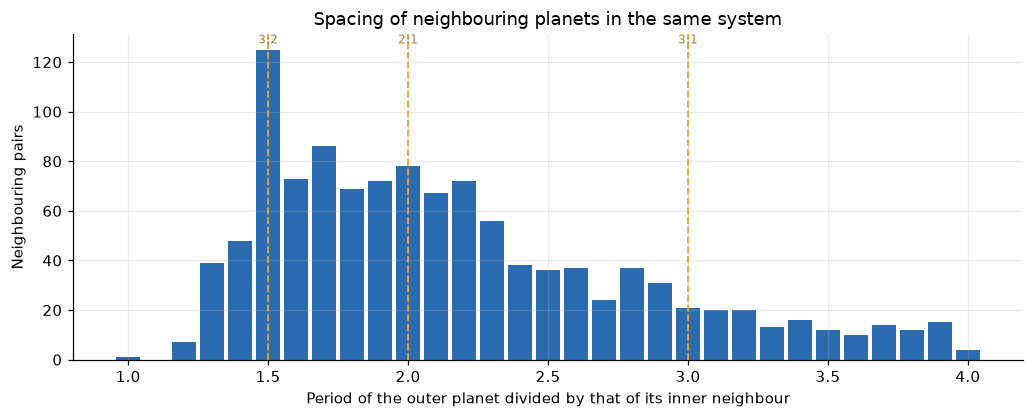

,period_ratio,neighbouring_pairs
4,1.5,125
6,1.7,86
9,2.0,78
5,1.6,73
11,2.2,72


In [9]:
resonance = q("""
WITH s AS (
    SELECT host, period_days,
           LAG(period_days) OVER (PARTITION BY host ORDER BY period_days) AS inner_period
    FROM planets
    WHERE period_days IS NOT NULL
)
SELECT ROUND(period_days / inner_period, 1)  AS period_ratio,
       COUNT(*)                              AS neighbouring_pairs
FROM s
WHERE inner_period IS NOT NULL AND period_days / inner_period < 4
GROUP BY period_ratio
ORDER BY period_ratio
""")

fig, ax = plt.subplots(figsize=(9.5, 3.9))
ax.bar(resonance.period_ratio, resonance.neighbouring_pairs, width=0.085, color=BLUE)
for x, label in [(1.5, "3:2"), (2.0, "2:1"), (3.0, "3:1")]:
    ax.axvline(x, color=AMBER, lw=1.2, ls="--")
    ax.text(x, resonance.neighbouring_pairs.max() * 1.02, label, ha="center", fontsize=8, color="#b7791f")
ax.set_xlabel("Period of the outer planet divided by that of its inner neighbour")
ax.set_ylabel("Neighbouring pairs")
ax.set_title("Spacing of neighbouring planets in the same system")
fig.tight_layout()
plt.show()
resonance.sort_values("neighbouring_pairs", ascending=False).head(5)

## 8. What stars do they orbit?

Host stars are split by effective temperature (`CASE`) into rough spectral classes. Per class: how many planets, how many distinct stars (`COUNT(DISTINCT)`), planets per star, and the share of the transiting planets that are under 2 Earth radii.

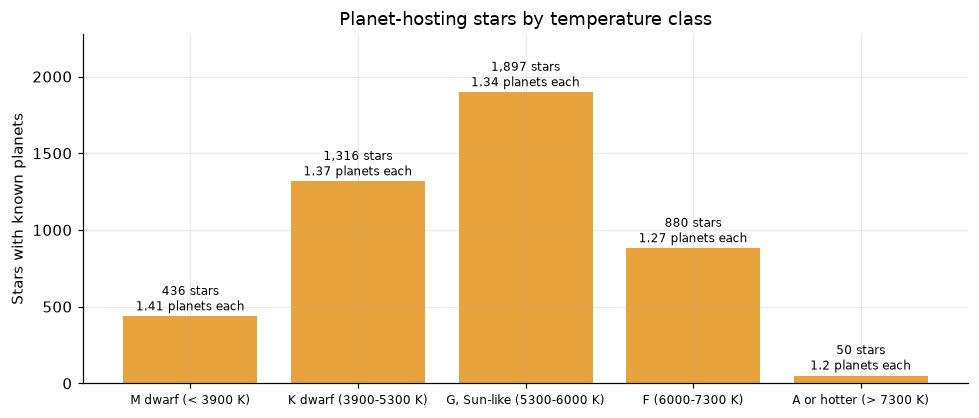

,star_class,planets,stars,planets_per_star,transiting_under_2_earths_pct,avg_distance_pc
0,1) M dwarf (< 3900 K),616,436,1.41,57.9,79.0
1,2) K dwarf (3900-5300 K),1797,1316,1.37,39.8,326.0
2,"3) G, Sun-like (5300-6000 K)",2551,1897,1.34,31.1,589.0
3,4) F (6000-7300 K),1114,880,1.27,27.4,676.0
4,5) A or hotter (> 7300 K),60,50,1.20,4.0,411.0


In [10]:
stars = q("""
SELECT CASE WHEN star_teff_k < 3900 THEN '1) M dwarf (< 3900 K)'
            WHEN star_teff_k < 5300 THEN '2) K dwarf (3900-5300 K)'
            WHEN star_teff_k < 6000 THEN '3) G, Sun-like (5300-6000 K)'
            WHEN star_teff_k < 7300 THEN '4) F (6000-7300 K)'
            ELSE                         '5) A or hotter (> 7300 K)' END    AS star_class,
       COUNT(*)                                                              AS planets,
       COUNT(DISTINCT host)                                                  AS stars,
       ROUND(1.0 * COUNT(*) / COUNT(DISTINCT host), 2)                       AS planets_per_star,
       ROUND(100.0 * AVG(CASE WHEN radius_source = 'measured (transit)' THEN radius_earth < 2 END), 1) AS transiting_under_2_earths_pct,
       ROUND(AVG(distance_pc))                                               AS avg_distance_pc
FROM planets
WHERE star_teff_k IS NOT NULL
GROUP BY star_class
ORDER BY star_class
""")

fig, ax = plt.subplots(figsize=(9, 3.9))
ax.bar(stars.star_class.str[3:], stars.stars, color=AMBER)
for x, (n, p) in enumerate(zip(stars.stars, stars.planets_per_star)):
    ax.text(x, n + 40, f"{n:,} stars\n{p} planets each", ha="center", fontsize=8)
ax.set_ylim(0, stars.stars.max() * 1.2)
ax.set_ylabel("Stars with known planets")
ax.set_title("Planet-hosting stars by temperature class")
ax.tick_params(axis="x", labelsize=8)
fig.tight_layout()
plt.show()
stars

## 9. When does a planet turn from rock to gas?

Bulk density follows from mass and radius: `5.51 * mass / radius^3` in g/cm3 (Earth is 5.51). Only transiting planets with a *measured* mass count, because an estimated mass would make the answer circular. A few values are physically impossible (above 30 g/cm3, denser than anything known), which come from badly constrained masses or radii, so they are counted and excluded, and the median per radius bin is used.

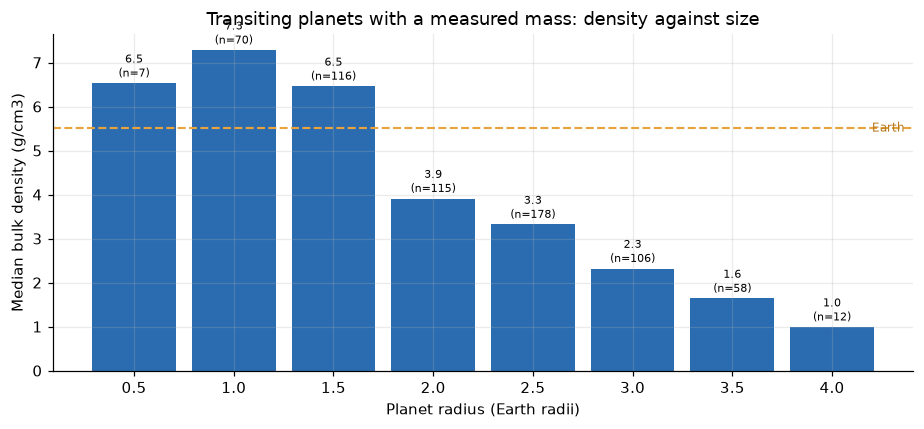

,radius_bin,planets,median_density_g_cm3,impossible_excluded
0,0.5,7,6.53,6
1,1.0,70,7.28,20
2,1.5,116,6.46,19
3,2.0,115,3.91,15
4,2.5,178,3.32,11
5,3.0,106,2.32,7
6,3.5,58,1.64,2
7,4.0,12,0.99,3


In [11]:
density = q("""
WITH d AS (
    SELECT ROUND(radius_earth * 2) / 2                       AS radius_bin,
           5.51 * mass_earth / POWER(radius_earth, 3)        AS density
    FROM planets
    WHERE mass_source = 'measured' AND radius_source = 'measured (transit)'
      AND radius_earth BETWEEN 0.5 AND 4 AND mass_earth > 0
),
ok AS (SELECT * FROM d WHERE density <= 30),
r AS (
    SELECT radius_bin, density,
           ROW_NUMBER() OVER (PARTITION BY radius_bin ORDER BY density) AS rn,
           COUNT(*)     OVER (PARTITION BY radius_bin)                  AS n
    FROM ok
)
SELECT radius_bin,
       n                                   AS planets,
       ROUND(AVG(density), 2)              AS median_density_g_cm3,
       (SELECT COUNT(*) FROM d WHERE d.radius_bin = r.radius_bin AND d.density > 30) AS impossible_excluded
FROM r
WHERE rn IN ((n + 1) / 2, (n + 2) / 2)
GROUP BY radius_bin
ORDER BY radius_bin
""")

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(density.radius_bin, density.median_density_g_cm3, width=0.42, color=BLUE)
for x, v, n in zip(density.radius_bin, density.median_density_g_cm3, density.planets):
    ax.text(x, v + 0.15, f"{v:.1f}\n(n={n})", ha="center", fontsize=7.5)
ax.axhline(5.51, color=AMBER, lw=1.4, ls="--")
ax.text(density.radius_bin.max() + 0.2, 5.51, "Earth", color="#b7791f", fontsize=8, va="center")
ax.set_xlabel("Planet radius (Earth radii)")
ax.set_ylabel("Median bulk density (g/cm3)")
ax.set_title("Transiting planets with a measured mass: density against size")
fig.tight_layout()
plt.show()
density

## 10. Which planets look most like Earth?

A crude similarity score: the distance from Earth in (log radius, log insolation) space, `ABS(LN(radius)) + ABS(LN(insolation))`, for rocky-sized transiting planets (0.5 to 1.6 Earth radii, radius observed) that receive between 0.3 and 1.5 times Earth's stellar flux. It says nothing about atmospheres or habitability. Famous non-transiting neighbours such as Proxima b are absent because their radius is only an estimate.

In [12]:
earthlike = q("""
SELECT planet, host,
       ROUND(radius_earth, 2)                                            AS radius_earth,
       ROUND(insolation_earth, 2)                                        AS insolation_earth,
       ROUND(distance_pc * 3.2616)                                       AS distance_light_years,
       mass_source,
       ROUND(ABS(LN(radius_earth)) + ABS(LN(insolation_earth)), 2)       AS distance_from_earth,
       disc_year
FROM planets
WHERE radius_source = 'measured (transit)' AND radius_earth BETWEEN 0.5 AND 1.6 AND insolation_earth BETWEEN 0.3 AND 1.5
ORDER BY distance_from_earth
LIMIT 12
""")

earthlike

,planet,host,radius_earth,insolation_earth,distance_light_years,mass_source,distance_from_earth,disc_year
0,TOI-700 d,TOI-700,1.15,0.85,102.0,estimated from radius,0.30,2020
1,TOI-700 e,TOI-700,0.92,1.27,102.0,estimated from radius,0.32,2023
2,TRAPPIST-1 d,TRAPPIST-1,0.79,1.11,41.0,measured,0.35,2016
3,Kepler-1649 c,Kepler-1649,1.06,0.75,301.0,estimated from radius,0.35,2020
4,LP 890-9 c,LP 890-9,1.37,0.91,106.0,measured,0.41,2022
5,K2-72 e,K2-72,1.29,1.20,217.0,estimated from radius,0.44,2016
6,Kepler-438 b,Kepler-438,1.12,1.40,639.0,estimated from radius,0.45,2015
7,TRAPPIST-1 e,TRAPPIST-1,0.92,0.65,41.0,measured,0.52,2017
8,Kepler-1652 b,Kepler-1652,1.60,0.81,822.0,estimated from radius,0.68,2017
9,Kepler-442 b,Kepler-442,1.34,0.66,1194.0,estimated from radius,0.71,2015


## 11. Which planetary systems are the closest?

Planets grouped by host star: the distance, the number of known planets, the star's temperature and a running count of systems within each distance with `COUNT(*) OVER (ORDER BY distance)`.

In [13]:
nearest = q("""
SELECT host,
       ROUND(MIN(distance_pc) * 3.2616, 1)                                  AS distance_light_years,
       COUNT(*)                                                             AS planets,
       ROUND(MIN(star_teff_k))                                              AS star_temperature_k,
       GROUP_CONCAT(planet, ', ')                                           AS planet_names,
       COUNT(*) OVER (ORDER BY MIN(distance_pc))                            AS systems_up_to_here
FROM planets
WHERE distance_pc IS NOT NULL
GROUP BY host
ORDER BY MIN(distance_pc)
LIMIT 12
""")

nearest

,host,distance_light_years,planets,star_temperature_k,planet_names,systems_up_to_here
0,Proxima Cen,4.2,2,2900.0,"Proxima Cen d, Proxima Cen b",1
1,Barnard's star,6.0,4,3195.0,"Barnard d, Barnard c, Barnard b, Barnard e",2
2,eps Eri,10.4,1,5020.0,eps Eri b,3
3,GJ 887,10.7,4,3688.0,"GJ 887 e, GJ 887 c, GJ 887 b, GJ 887 d",4
4,Ross 128,11.0,1,3192.0,Ross 128 b,5
5,Gl 725 A,11.5,1,3433.0,Gl 725 A b,6
6,GJ 15 A,11.6,2,3607.0,"GJ 15 A b, GJ 15 A c",7
7,tau Cet,11.8,3,5310.0,"tau Cet g, tau Cet f, tau Cet h",8
8,eps Ind A,11.9,1,4700.0,eps Ind A b,9
9,GJ 1061,12.0,3,2953.0,"GJ 1061 d, GJ 1061 b, GJ 1061 c",10


## What the queries say

- **Three quarters of all known planets were found by one method.** Transit accounts for 4,781 of 6,445 planets (74.2%), radial velocity for 1,203 (18.7%), microlensing for 292 and direct imaging for 97. The methods see different planets: the median observed mass is 64 Earth masses for transiting planets, 349 for radial velocity and about 4,000 (12.5 Jupiter masses) for imaged ones, and the average distance is 84 parsecs for radial velocity but 579 for transits and over 5,000 for microlensing, which looks towards the centre of the galaxy.
- **Two space telescopes found most of them.** Kepler has 2,787 planets (43.2%) and TESS 1,008 (15.6%), and K2 (Kepler's second mission) 550, so three space missions hold 67% of the catalogue. The best ground facilities are La Silla (311, radial velocity) and Keck (193).
- **The yearly count is driven by a few big announcements.** About 100 planets a year were found in 2010-13, then 872 in 2014 and 1,504 in 2016 (together 37% of everything) when the Kepler team confirmed planets in large batches, 564 in 2021 and 355 so far in 2026. The count of planets found by radial velocity has stayed between 29 and 115 a year for a decade.
- **The planets we find are mostly not like the ones in the Solar System.** Of 4,808 transiting planets, 39.5% are sub-Neptunes of 2 to 4 Earth radii and 23.6% are 1.25 to 2 Earth radii, two classes that do not exist in the Solar System. Short orbits dominate: 79% of the Earth-sized planets and 69% of the Jupiter-sized ones orbit in under 10 days, which is mostly a consequence of how the transit method works (close planets transit more often and are more likely to be aligned).
- **The "radius valley" shows up in the data.** For planets on orbits under 100 days, the count per 0.1 Earth radius bin is 160 to 170 from 1.2 to 1.6 Earth radii, falls to 144, 131 and 113 at 1.7, 1.8 and 1.9, and recovers to 146 at 2.0 and 171 at 2.3. The dip of about 30% is the known gap between rocky planets and planets with thick gas envelopes, though this sample mixes surveys of very different sensitivity.
- **Density changes where the valley is.** Among transiting planets with a measured mass, the median bulk density is 6.5 to 7.3 g/cm3 up to 1.5 Earth radii (Earth is 5.51), 3.9 at 2.0, 2.3 at 3.0 and 1.0 at 4.0 radii. The transition from rock to low-density gas happens between 1.5 and 2 Earth radii. In 83 of 831 planets (10%) the computed density is impossibly high (above 30 g/cm3), because of badly constrained masses, and these are excluded.
- **Hot Jupiters were a selection effect of the first surveys.** Every planet found by transits up to 2008 was a hot Jupiter, 78% in 2009, 70% in 2010, only 15% in 2013 and 5.7% in 2016 when Kepler's small planets came in. The share is back to 40% of newly found transiting planets in 2025, because ground surveys and TESS favour large planets. These shares describe what is easy to detect, not how common hot Jupiters are in the galaxy.
- **Neighbouring planets cluster near a 3:2 period ratio.** In multi-planet systems, 125 neighbouring pairs fall in the 1.5 bin against about 70 to 86 in the bins on either side, while a 2:1 ratio shows no peak (78 pairs against 72 and 67 next to it) and pairs closer than 1.25 are rare (8). Planets not yet discovered between two known ones make some pairs look wider than they are.
- **Small planets are over-represented around small stars, but that is partly detection.** Of the transiting planets around M dwarfs, 58% are under 2 Earth radii, against 31% around Sun-like stars and 4% around the hottest stars. A small planet blocks a larger share of a small star's light, so it is easier to see there, and this does not tell us how many small planets each type of star has. M dwarfs are also closer (79 parsecs on average, against 589 for Sun-like stars).
- **Only measured radii were used to rank Earth-like planets.** The top candidates by a simple similarity in size and received light are TOI-700 d and e (about 102 light years away), TRAPPIST-1 d and e (41 light years) and Kepler-1649 c. Five of the top eight have a mass that is only estimated from the radius. Proxima b and Teegarden's Star b do not appear, since only their minimum masses are measured and their radii are estimates.
- **The nearest planetary systems are all around small, cool stars.** Proxima Centauri (4.2 light years, two planets) and Barnard's star (6.0, four planets) lead a list of 12 systems within 12.5 light years, and nine of the 12 have M dwarfs (cool red stars) as hosts.

**Limits.** Masses are estimated from radius for 47% of planets, and radii are estimated for planets that do not transit, so size and density questions use only transiting planets. The archive merges values from many publications, with different methods and precision. The similarity to Earth ignores the star's type, the atmosphere and the planet's mass, and says nothing about habitability.
